# Project Milestone Two: Modeling and Feature Engineering

### Overview

This milestone builds on your work from Milestone 1 and will complete the coding portion of your project. You will:

1. Pick 3 modeling algorithms from those we have studied.
2. Evaluate baseline models using default settings.
3. Engineer new features and re-evaluate models.
4. Use feature selection techniques and re-evaluate.
5. Fine-tune for optimal performance.
6. Select your best model and report on your results. 

You must do all work in this notebook and upload to your team leader's account in Gradescope. There is no
Individual Assessment for this Milestone. 


In [7]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

import time



### Prelude: Load your Preprocessed Dataset from Milestone 1

In Milestone 1, you handled missing values, encoded categorical features, and explored your data. Before you begin this milestone, you’ll need to load that cleaned dataset and prepare it for modeling. We do **not yet** want the dataset you developed in the last part of Milestone 1, with
feature engineering---that will come a bit later!

Here’s what to do:

1. Return to your Milestone 1 notebook and rerun your code through Part 3, where your dataset was fully cleaned (assume it’s called `df_cleaned`).

2. **Save** the cleaned dataset to a file by running:

>   df_cleaned.to_csv("zillow_cleaned.csv", index=False)

3. Switch to this notebook and **load** the saved data:

>   df = pd.read_csv("zillow_cleaned.csv")

4. Create a **train/test split** using `train_test_split`.  
   
6. **Standardize** the features (but not the target!) using **only the training data.** This ensures consistency across models without introducing data leakage from the test set:

>   scaler = StandardScaler()   
>   X_train_scaled = scaler.fit_transform(X_train)    
  
**Notes:** 

- You will have to redo the scaling step if you introduce new features (which have to be scaled as well).


In [3]:
df = pd.read_csv("zillow_cleaned.csv")

In [4]:
# Add as many cells as you need
df.head()

,airconditioningtypeid,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedfinishedsquarefeet,garagecarcnt,garagetotalsqft,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,propertylandusetypeid,propertyzoningdesc,regionidcounty,roomcnt,unitcnt,yearbuilt,taxvaluedollarcnt
0,1.0,3.5,4.0,6.0,3100.0,2.0,633.0,2.0,33634931.0,-117869207.0,4506.0,261.0,580.0,1286.0,0.0,1.0,1998.0,1023282.0
1,1.0,1.0,2.0,6.0,1465.0,1.0,0.0,2.0,34449266.0,-119281531.0,12647.0,261.0,580.0,2061.0,5.0,1.0,1967.0,464000.0
2,1.0,2.0,3.0,6.0,1243.0,2.0,440.0,2.0,33886168.0,-117823170.0,8432.0,261.0,580.0,1286.0,6.0,1.0,1962.0,564778.0
3,1.0,3.0,4.0,8.0,2376.0,2.0,456.0,2.0,34245180.0,-118240722.0,13038.0,261.0,797.0,3101.0,0.0,1.0,1970.0,145143.0
4,1.0,3.0,3.0,8.0,1312.0,2.0,456.0,2.0,34185120.0,-118414640.0,278581.0,266.0,587.0,3101.0,0.0,1.0,1964.0,119407.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70791 entries, 0 to 70790
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   airconditioningtypeid         70791 non-null  float64
 1   bathroomcnt                   70791 non-null  float64
 2   bedroomcnt                    70791 non-null  float64
 3   buildingqualitytypeid         70791 non-null  float64
 4   calculatedfinishedsquarefeet  70791 non-null  float64
 5   garagecarcnt                  70791 non-null  float64
 6   garagetotalsqft               70791 non-null  float64
 7   heatingorsystemtypeid         70791 non-null  float64
 8   latitude                      70791 non-null  float64
 9   longitude                     70791 non-null  float64
 10  lotsizesquarefeet             70791 non-null  float64
 11  propertylandusetypeid         70791 non-null  float64
 12  propertyzoningdesc            70791 non-null  float64
 13  regionidcoun

### Part 1: Picking Three Models and Establishing Baselines [6 pts]

Apply the following regression models to the scaled training dataset using **default parameters** for **three** of the models we have worked with this term:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Bagging
- Random Forest
- Gradient Boosting Trees

For each of the three models:
- Use **repeated cross-validation** (e.g., 5 folds, 5 repeats).
- Report the **mean and standard deviation of CV MAE Score**. 


In [6]:
# Add as many cells as you need

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1: Separate features and target
X = df.drop(columns=['taxvaluedollarcnt'])
y = df['taxvaluedollarcnt']

# Step 2: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Scale using training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform only, NOT fit_transform

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set:     {X_test_scaled.shape}")


Training set: (56632, 17)
Test set:     (14159, 17)


In [7]:
# ============================================================
# MILESTONE 2 — MODEL BASELINES
# All models tested, and use default parameters, repeated CV (5x5)
# and report Mean/Std CV MAE
# ============================================================


# ============================================================
# Cross-validation strategy — defined once, used for all models
# 5 folds × 5 repeats = 25 scores per model
# random_state=42 ensures reproducibility
# ============================================================
cv_strategy = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

# ============================================================
# Define all models in a dictionary
# Easier to loop through all models and add/remove
# models without changing the evaluation code
# Default parameters, no tuning yet, this is just the baseline
# ============================================================
models = {
    'Linear Regression':          LinearRegression(),
    'Ridge (L2)':                 Ridge(),
    'Lasso (L1)':                 Lasso(),
    'Decision Tree':              DecisionTreeRegressor(random_state=42),
    'Bagging':                    BaggingRegressor(random_state=42),
    'Random Forest':              RandomForestRegressor(random_state=42),
    'Gradient Boosting':          GradientBoostingRegressor(random_state=42),
    'Histogram Boosting':         HistGradientBoostingRegressor(random_state=42)
}

# ============================================================
# Run CV for all models and store results
# Loop through each model, run CV on the scaled training 
# data, record mean MAE, std MAE, and how long it took to run
# ============================================================
results = []

for name, model in models.items():
    print(f"Running: {name}...", end=' ')
    
    # Track how long each model takes, which is useful to know 
    # especially for slower ensemble methods
    start_time = time.time()
    
    # Run repeated cross-validation on training data only
    # neg_mean_absolute_error returns negative values by 
    # convention, so multiply by -1 to get positive MAE
    cv_scores = cross_val_score(
        model,
        X_train_scaled,    # scaled training features
        y_train,           # training target
        cv=cv_strategy,
        scoring='neg_mean_absolute_error',
        n_jobs=-1          # use all CPU cores to speed things up
    )
    
    elapsed = time.time() - start_time
    cv_mae = -cv_scores
    
    # Store results for this model
    results.append({
        'Model':        name,
        'Mean CV MAE':  cv_mae.mean(),
        'Std CV MAE':   cv_mae.std(),
        'Min CV MAE':   cv_mae.min(),
        'Max CV MAE':   cv_mae.max(),
        'Time (s)':     round(elapsed, 1)
    })
    
    print(f"Done — Mean MAE: ${cv_mae.mean():,.0f} | Std: ${cv_mae.std():,.0f} | Time: {elapsed:.1f}s")

# ============================================================
# Build results dataframe
# Sort by Mean CV MAE so best models appear at the top
# Lower MAE = better performance
# ============================================================
results_df = pd.DataFrame(results).sort_values('Mean CV MAE')

print("\n")
print("=" * 75)
print("MODEL COMPARISON — Repeated CV Results (5 folds × 5 repeats)")
print("=" * 75)
print(results_df[['Model', 'Mean CV MAE', 'Std CV MAE', 'Time (s)']].to_string(
    index=False,
    formatters={
        'Mean CV MAE': '${:>12,.0f}'.format,
        'Std CV MAE':  '${:>12,.0f}'.format,
        'Time (s)':    '{:>8.1f}s'.format
    }
))

Running: Linear Regression... Done — Mean MAE: $257,661 | Std: $3,282 | Time: 6.6s
Done — Mean MAE: $257,657 | Std: $3,283 | Time: 0.5s
Done — Mean MAE: $257,660 | Std: $3,282 | Time: 1.1s
Done — Mean MAE: $266,570 | Std: $4,361 | Time: 3.7s
Done — Mean MAE: $209,263 | Std: $3,411 | Time: 17.6s
Done — Mean MAE: $201,045 | Std: $3,456 | Time: 176.7s
Done — Mean MAE: $210,317 | Std: $3,763 | Time: 60.0s
Done — Mean MAE: $204,429 | Std: $3,478 | Time: 4.1s


MODEL COMPARISON — Repeated CV Results (5 folds × 5 repeats)
             Model   Mean CV MAE    Std CV MAE  Time (s)
     Random Forest $     201,045 $       3,456    176.7s
Histogram Boosting $     204,429 $       3,478      4.1s
           Bagging $     209,263 $       3,411     17.6s
 Gradient Boosting $     210,317 $       3,763     60.0s
        Ridge (L2) $     257,657 $       3,283      0.5s
        Lasso (L1) $     257,660 $       3,282      1.1s
 Linear Regression $     257,661 $       3,282      6.6s
     Decision Tree $   

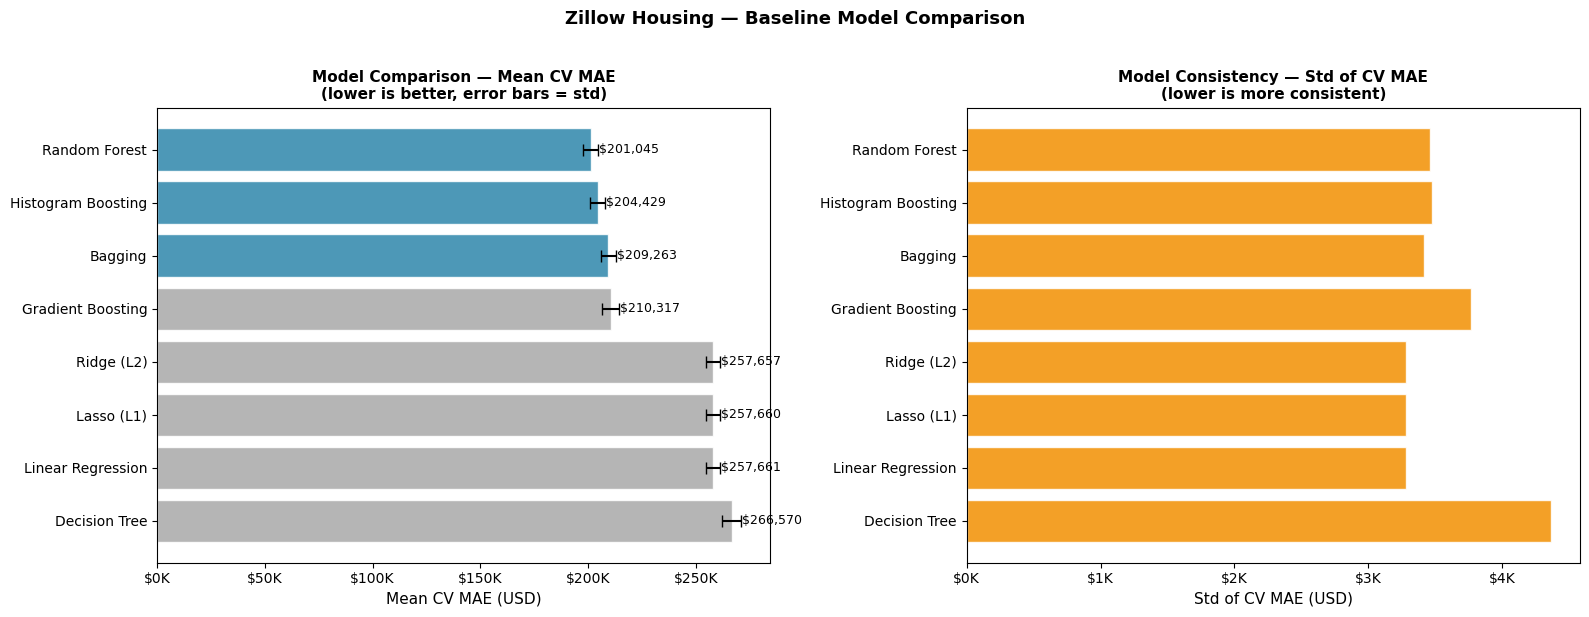

In [8]:
# ============================================================
# VISUALIZATION 1: Bar chart of Mean CV MAE with error bars
# Error bars show the standard deviation, wider bars mean 
# less consistent performance across folds
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sort by mean MAE for clean display
plot_df = results_df.sort_values('Mean CV MAE')

# --- Left plot: Mean CV MAE with std error bars ---
colors = ['#2E86AB' if i < 3 else '#A8A8A8' for i in range(len(plot_df))]
bars = axes[0].barh(
    plot_df['Model'],
    plot_df['Mean CV MAE'],
    xerr=plot_df['Std CV MAE'],
    color=colors,
    edgecolor='white',
    capsize=4,
    alpha=0.85
)

# Add value labels on each bar
for bar, val, std in zip(bars, plot_df['Mean CV MAE'], plot_df['Std CV MAE']):
    axes[0].text(
        bar.get_width() + std + 500,
        bar.get_y() + bar.get_height() / 2,
        f'${val:,.0f}',
        va='center', fontsize=9
    )

axes[0].set_xlabel('Mean CV MAE (USD)', fontsize=11)
axes[0].set_title('Model Comparison — Mean CV MAE\n(lower is better, error bars = std)', 
                   fontsize=11, fontweight='bold')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)
axes[0].invert_yaxis()

# --- Right plot: Std CV MAE — model consistency ---
# Lower std = more consistent/reliable model
axes[1].barh(
    plot_df['Model'],
    plot_df['Std CV MAE'],
    color='#F18F01',
    edgecolor='white',
    alpha=0.85
)
axes[1].set_xlabel('Std of CV MAE (USD)', fontsize=11)
axes[1].set_title('Model Consistency — Std of CV MAE\n(lower is more consistent)', 
                   fontsize=11, fontweight='bold')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)
axes[1].invert_yaxis()

plt.suptitle('Zillow Housing — Baseline Model Comparison', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

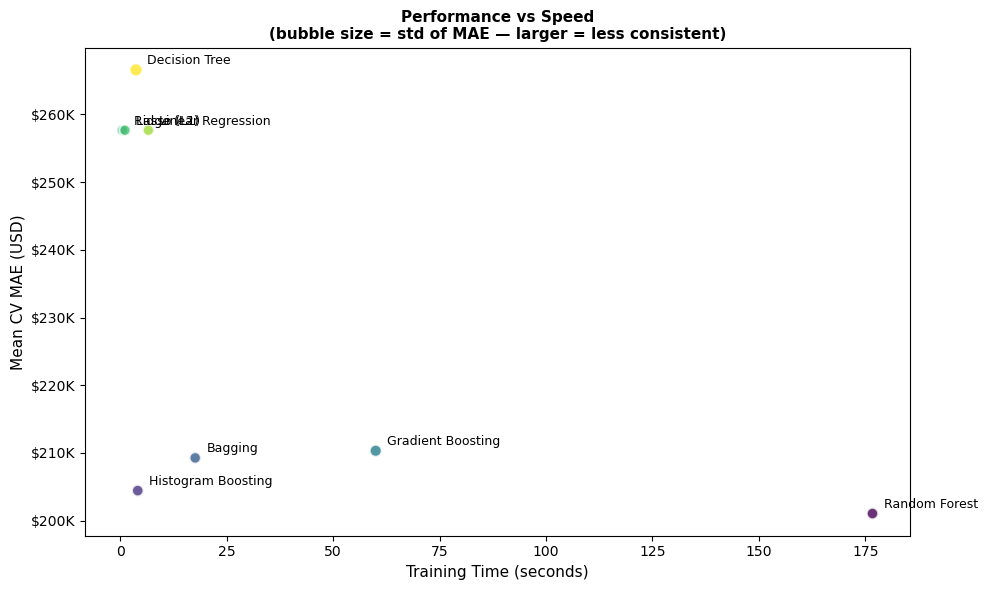

In [9]:
# ============================================================
# VISUALIZATION 2 — Scatter plot: Performance vs Speed
# Helps identify if a slower model is actually worth the 
# extra computation time compared to a faster one
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    results_df['Time (s)'],
    results_df['Mean CV MAE'],
    s=results_df['Std CV MAE'] / 50,  # bubble size = uncertainty
    c=range(len(results_df)),
    cmap='viridis',
    alpha=0.8,
    edgecolors='white',
    linewidth=1.5
)

# Label each point with the model name
for _, row in results_df.iterrows():
    ax.annotate(
        row['Model'],
        (row['Time (s)'], row['Mean CV MAE']),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=9
    )

ax.set_xlabel('Training Time (seconds)', fontsize=11)
ax.set_ylabel('Mean CV MAE (USD)', fontsize=11)
ax.set_title('Performance vs Speed\n(bubble size = std of MAE — larger = less consistent)', 
             fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)

plt.tight_layout()
plt.savefig('performance_vs_speed.png', dpi=150, bbox_inches='tight')
plt.show()

### Part 1: Discussion [3 pts]

In a paragraph or well-organized set of bullet points, briefly compare and discuss:

  - Which model performed best overall?
  - Which was most stable (lowest std)?
  - Any signs of overfitting or underfitting?

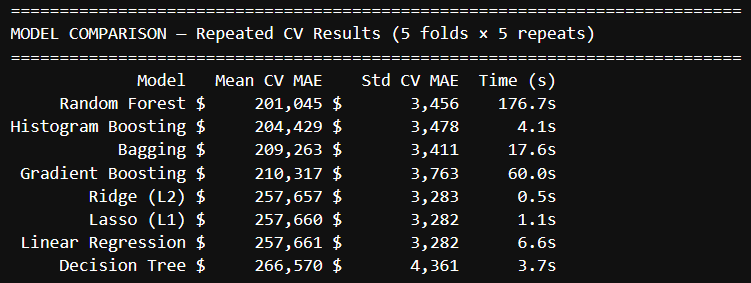

MAE is a metric to measure the accuracy of a predictive model, determining on average, how far off a model's prediction is from the actual values. MAE is measured in the same units as the target variable, 'taxvaluedollarcnt'.  A lower MAE indicates better performance, with MAE = 0 being a perfect model. The current models are establishing baseline values, utilizing default parameters on the training data. There has been no hyperparameter tuning or feature engineering beyond what was applied in Milestone 1.  

Model Comparison - Baseline results, default settings, no parameter tuning

**Best Performance (Mean CV MAE):**

* Random Forest performed the best at default parameters with a Mean CV MAE of `$201,045`, however, it had a long training time of 176.7 seconds
* Histogram Boosting performed second best at `$204,429` and had a training time of 4.1 seconds
* Bagging and Gradient Boosting were close, and performed third and fourth best, at `$209,263` and `$210,317` respectively. The training times were 17.6 and 60.0 seconds
* Each of these four models outperformed the linear models (Linear, Ridge and Lasso), which were clustered around `$257,600`, approximately `$56,000` worse than the previous better-performing models, suggesting the relationship between the features and home values is non-linear, which tree-based models capture better.

**Most Stable (Lowest STD):**

* Ridge and Lasso were the most consistent models with a Std CV MAE of `$3,282`, followed closely by Linear Regression also at `$3,282`
* The tree-based models had slightly higher std values, with Decision Tree being the least consistent at `$4,361`
* However the differences in std across all models are relatively small (`$3,282` to `$4,361`), suggesting all models are reasonably stable across the 25 CV folds


Signs of Overfitting or Underfitting:

* The Decision Tree may show signs of overfitting. It has the worst CV MAE (`$266,570`) despite being a flexible model, suggesting it is memorizing noise in the training data rather than learning generalizable patterns
* The linear models show signs of underfitting. Their performance is nearly identical (`$257,657`– `$257,661`) regardless of regularization suggests they may not be able to capture the nonlinear relationships identified in Milestone 1
* The ensemble models (Random Forest, Histogram Boosting, Bagging) show the best balance, with strong performance and relatively low variance, indicating they generalize well without overfitting

Worth noting is that the linear models appear to be more stable with lower std's than the tree-based models, however, this is opposite for the MAE performance. So the stability comes at a cost of performance, with linear models more reliable, but "reliably mediocre", while the tree-based models were less consistent, but more accurate.

> Your text here

### Part 2: Feature Engineering [6 pts]

Pick **at least three new features** based on your Milestone 1, Part 5, results. You may pick new ones or
use the same ones you chose for Milestone 1. 

Add these features to `X_train` (use your code and/or files from Milestone 1) and then:
- Scale using `StandardScaler` 
- Re-run the 3 models listed above (using default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [10]:
# ============================================================
# Part 2: Feature Engineering — Add Three New Features
# Based on Milestone 1 Part 5 analysis
# Three engineered features added: 'sqft_x_bath', 'log_sqft', 'log_lotsize'
# ============================================================

# Step 1: Copy the cleaned dataset so we don't modify the original
df_engineered = df.copy()

# ============================================================
# Feature 1: sqft_x_bath
# Interaction feature — calculatedfinishedsquarefeet × bathroomcnt
# This captures the combined effect of size and bathroom count,
# which was the strongest predictor in Milestone 1 Part 5 
# with an F-score of 50,762 — higher than any individual feature
# ============================================================
df_engineered['sqft_x_bath'] = (df_engineered['calculatedfinishedsquarefeet'] * 
                                 df_engineered['bathroomcnt'])

# ============================================================
# Feature 2: log_sqft
# Log transformation of calculatedfinishedsquarefeet
# calculatedfinishedsquarefeet is heavily right-skewed with 
# outliers, so the log transformation stabilizes variance and 
# compresses the extreme values, producing a more symmetric 
# distribution. F-score of 20,139 in Milestone 1 Part 5.
# np.log1p is used instead of np.log to safely handle any 
# zero values — log1p computes log(x + 1)
# ============================================================
df_engineered['log_sqft'] = np.log1p(df_engineered['calculatedfinishedsquarefeet'])

# ============================================================
# Feature 3: log_lotsize
# Log transformation of lotsizesquarefeet
# lotsizesquarefeet had the most extreme right skew of all 
# features in Milestone 1 EDA, with 16.5% outliers identified
# by IQR analysis. Log transformation is strongly justified 
# to reduce the influence of very large lot sizes.
# ============================================================
df_engineered['log_lotsize'] = np.log1p(df_engineered['lotsizesquarefeet'])

# ============================================================
# Verify the new features were created correctly
# ============================================================
print("New features added:")
print(df_engineered[['calculatedfinishedsquarefeet', 'bathroomcnt', 'sqft_x_bath',
                       'log_sqft', 'lotsizesquarefeet', 'log_lotsize']].head())

print(f"\nDataset shape before: {df.shape}")
print(f"Dataset shape after:  {df_engineered.shape}")
print(f"\nNew columns: {[c for c in df_engineered.columns if c not in df.columns]}")

New features added:
   calculatedfinishedsquarefeet  bathroomcnt  sqft_x_bath  log_sqft  \
0                        3100.0          3.5      10850.0  8.039480   
1                        1465.0          1.0       1465.0  7.290293   
2                        1243.0          2.0       2486.0  7.126087   
3                        2376.0          3.0       7128.0  7.773594   
4                        1312.0          3.0       3936.0  7.180070   

   lotsizesquarefeet  log_lotsize  
0             4506.0     8.413387  
1            12647.0     9.445254  
2             8432.0     9.039908  
3            13038.0     9.475700  
4           278581.0    12.537468  

Dataset shape before: (70791, 18)
Dataset shape after:  (70791, 21)

New columns: ['sqft_x_bath', 'log_sqft', 'log_lotsize']


In [11]:

# ============================================================
# Step 2: Redefine X and y using the engineered dataset
# We now use df_engineered which includes the 3 new features
# The target y remains the same, 'taxvaluedollarcnt'
# ============================================================
X_eng = df_engineered.drop(columns=['taxvaluedollarcnt'])
y_eng = df_engineered['taxvaluedollarcnt']

print(f"Features before engineering: {X.shape[1]}")
print(f"Features after engineering:  {X_eng.shape[1]}")
print(f"New features: {[c for c in X_eng.columns if c not in X.columns]}")

# ============================================================
# Step 3: Redo train/test split on engineered dataset
# Using same random_state=42 as before to ensure we get the 
# same split, this is important for fair comparison between 
# baseline models and engineered models
# ============================================================
X_eng_train, X_eng_test, y_eng_train, y_eng_test = train_test_split(
    X_eng, y_eng,
    test_size=0.2,
    random_state=42
)

print(f"\nTraining set size: {X_eng_train.shape[0]:,} rows × {X_eng_train.shape[1]} features")
print(f"Test set size:     {X_eng_test.shape[0]:,} rows × {X_eng_test.shape[1]} features")

# ============================================================
# Step 4: Refit scaler on new training data and transform
# IMPORTANT: We fit the scaler on training data ONLY
# fit_transform on training, learns the scale from training
# transform only on test, and applies same scale, no data leakage
# We must redo scaling because the three new features have 
# different scales and need to be standardized alongside the 
# existing features
# ============================================================
scaler_eng = StandardScaler()
X_eng_train_scaled = scaler_eng.fit_transform(X_eng_train)
X_eng_test_scaled  = scaler_eng.transform(X_eng_test)

print("\nScaling complete:")
print(f"X_eng_train_scaled shape: {X_eng_train_scaled.shape}")
print(f"X_eng_test_scaled shape:  {X_eng_test_scaled.shape}")

Features before engineering: 17
Features after engineering:  20
New features: ['sqft_x_bath', 'log_sqft', 'log_lotsize']

Training set size: 56,632 rows × 20 features
Test set size:     14,159 rows × 20 features

Scaling complete:
X_eng_train_scaled shape: (56632, 20)
X_eng_test_scaled shape:  (14159, 20)


In [27]:
# ============================================================
# Step 5: Re-run all models on engineered dataset
# Reusing the same models dictionary and cv_strategy from Part 1
# The only change is we now pass X_eng_train_scaled instead 
# of X_train_scaled; everything else stays identical so the 
# comparison is fair
# ============================================================
results_eng = []

for name, model in models.items():
    print(f"Running: {name}...", end=' ')
    
    start_time = time.time()
    
    cv_scores = cross_val_score(
        model,
        X_eng_train_scaled,    # engineered + scaled training features
        y_eng_train,           # training target
        cv=cv_strategy,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )
    
    elapsed = time.time() - start_time
    cv_mae = -cv_scores
    
    results_eng.append({
        'Model':        name,
        'Mean CV MAE':  cv_mae.mean(),
        'Std CV MAE':   cv_mae.std(),
        'Min CV MAE':   cv_mae.min(),
        'Max CV MAE':   cv_mae.max(),
        'Time (s)':     round(elapsed, 1)
    })
    
    print(f"Done — Mean MAE: ${cv_mae.mean():,.0f} | Std: ${cv_mae.std():,.0f} | Time: {elapsed:.1f}s")

# ============================================================
# Step 6: Build results dataframe and compare to baseline
# ============================================================
results_eng_df = pd.DataFrame(results_eng).sort_values('Mean CV MAE')

print("\n")
print("=" * 75)
print("ENGINEERED FEATURES — CV Results (5 folds × 5 repeats)")
print("=" * 75)
print(results_eng_df[['Model', 'Mean CV MAE', 'Std CV MAE', 'Time (s)']].to_string(
    index=False,
    formatters={
        'Mean CV MAE': '${:>12,.0f}'.format,
        'Std CV MAE':  '${:>12,.0f}'.format,
        'Time (s)':    '{:>8.1f}s'.format
    }
))

Running: Linear Regression... Done — Mean MAE: $241,022 | Std: $3,745 | Time: 0.9s
Done — Mean MAE: $241,020 | Std: $3,744 | Time: 0.4s
Done — Mean MAE: $241,021 | Std: $3,745 | Time: 7.9s
Done — Mean MAE: $267,954 | Std: $5,555 | Time: 4.0s
Done — Mean MAE: $210,058 | Std: $3,316 | Time: 23.6s
Done — Mean MAE: $201,324 | Std: $3,353 | Time: 247.3s
Done — Mean MAE: $210,174 | Std: $3,636 | Time: 68.0s
Done — Mean MAE: $204,755 | Std: $3,545 | Time: 4.3s


ENGINEERED FEATURES — CV Results (5 folds × 5 repeats)
             Model   Mean CV MAE    Std CV MAE  Time (s)
     Random Forest $     201,324 $       3,353    247.3s
Histogram Boosting $     204,755 $       3,545      4.3s
           Bagging $     210,058 $       3,316     23.6s
 Gradient Boosting $     210,174 $       3,636     68.0s
        Ridge (L2) $     241,020 $       3,744      0.4s
        Lasso (L1) $     241,021 $       3,745      7.9s
 Linear Regression $     241,022 $       3,745      0.9s
     Decision Tree $     267,



BASELINE vs ENGINEERED FEATURES — Direct Comparison
             Model Mean CV MAE Baseline Std CV MAE Baseline Mean CV MAE Engineered Std CV MAE Engineered Improvement
     Random Forest        $     201,045         $     3,456          $     201,324           $     3,353 $      -279
Histogram Boosting        $     204,429         $     3,478          $     204,755           $     3,545 $      -326
           Bagging        $     209,263         $     3,411          $     210,058           $     3,316 $      -795
 Gradient Boosting        $     210,317         $     3,763          $     210,174           $     3,636 $       143
        Ridge (L2)        $     257,657         $     3,283          $     241,020           $     3,744 $    16,638
        Lasso (L1)        $     257,660         $     3,282          $     241,021           $     3,745 $    16,639
 Linear Regression        $     257,661         $     3,282          $     241,022           $     3,745 $    16,639
     Decis

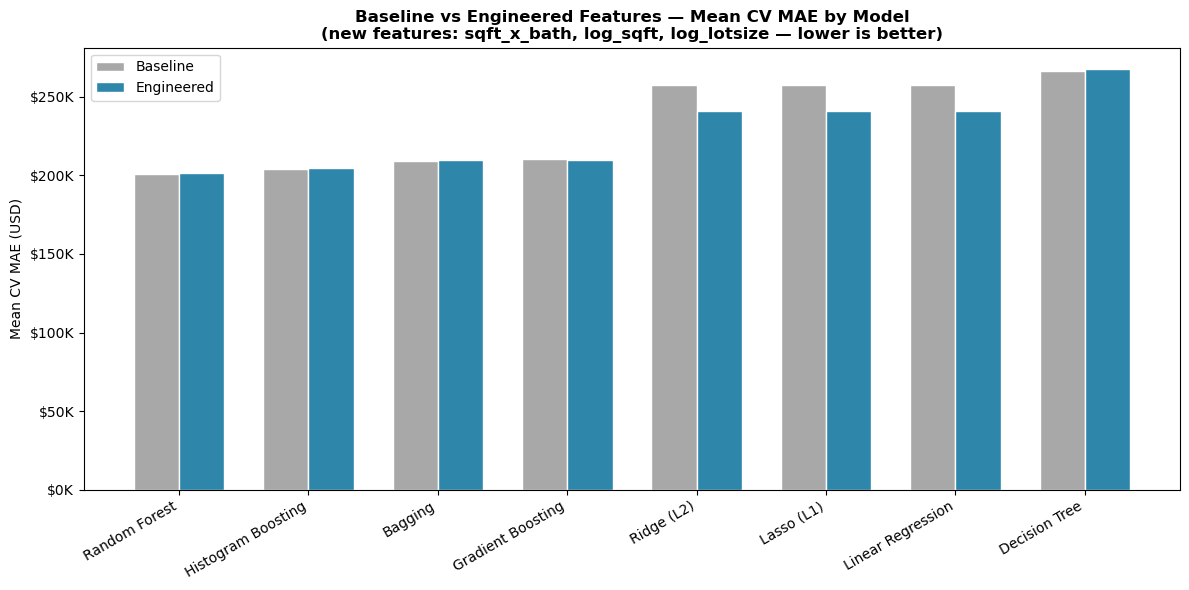

In [25]:
# ============================================================
# Step 7: Side by side comparison — Baseline vs Engineered
# Merges both results tables so you can directly compare 
# the impact of the three new features on each model
# ============================================================
comparison_df = results_df[['Model', 'Mean CV MAE', 'Std CV MAE']].merge(
    results_eng_df[['Model', 'Mean CV MAE', 'Std CV MAE']],
    on='Model',
    suffixes=(' Baseline', ' Engineered')
)

# Calculate improvement — positive = better with engineering
comparison_df['Improvement'] = (comparison_df['Mean CV MAE Baseline'] - 
                                 comparison_df['Mean CV MAE Engineered'])

comparison_df = comparison_df.sort_values('Mean CV MAE Engineered')

print("\n")
print("=" * 85)
print("BASELINE vs ENGINEERED FEATURES — Direct Comparison")
print("=" * 85)
print(comparison_df.to_string(
    index=False,
    formatters={
        'Mean CV MAE Baseline':    '${:>12,.0f}'.format,
        'Mean CV MAE Engineered':  '${:>12,.0f}'.format,
        'Std CV MAE Baseline':     '${:>10,.0f}'.format,
        'Std CV MAE Engineered':   '${:>10,.0f}'.format,
        'Improvement':             '${:>10,.0f}'.format
    }
))

# ============================================================
# Step 8: Visualize the comparison
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(comparison_df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], 
                comparison_df['Mean CV MAE Baseline'],
                width, label='Baseline', color='#A8A8A8', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], 
                comparison_df['Mean CV MAE Engineered'],
                width, label='Engineered', color='#2E86AB', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=30, ha='right')
ax.set_ylabel('Mean CV MAE (USD)')
ax.set_title(
    "Baseline vs Engineered Features — Mean CV MAE by Model\n"
    "(new features: sqft_x_bath, log_sqft, log_lotsize — lower is better)",
    fontweight='bold'
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend()

plt.tight_layout()
plt.savefig('baseline_vs_engineered.png', dpi=150, bbox_inches='tight')
plt.show()

Summary of teh addition of three engineered features, across all models:
The addition of three engineered features (sqft_x_bath, log_sqft, log_lotsize) had a different impact depending on model type. The linear models (Ridge, Lasso, Linear Regression) showed the most meaningful improvement, with Mean CV MAE dropping from approximately $257,600 to $241,000, a reduction of around $16,600. The tree-based models (Random Forest, Histogram Boosting, Bagging, Gradient Boosting) showed minimal change in either direction, confirming that tree-based models already discover these relationships during training.  Overall, the engineered features add more value to linear models than tree-based models, though the tree-based models remain the clear top performers regardless of feature engineering at default parameters.

In [15]:
# ============================================================
# Define candidate features to test individually, all possible features, across all model types
# (run time is about 35-40 minutes)
# ============================================================
candidate_features = {
    'sqft_x_bath':    df['calculatedfinishedsquarefeet'] * df['bathroomcnt'],
    'log_sqft':       np.log1p(df['calculatedfinishedsquarefeet']),
    'log_lotsize':    np.log1p(df['lotsizesquarefeet']),
    'property_age':   2016 - df['yearbuilt'],
    'bed_bath_ratio': df['bedroomcnt'] / (df['bathroomcnt'] + 1),
    'sqft_per_room':  df['calculatedfinishedsquarefeet'] / (df['roomcnt'] + 1),
    'lat_x_lon':      df['latitude'] * df['longitude'],
    'garage_ratio':   df['garagetotalsqft'] / (df['calculatedfinishedsquarefeet'] + 1)
}

# Define all eight models
test_models = {
    'Linear Regression':  LinearRegression(),
    'Ridge (L2)':         Ridge(),
    'Lasso (L1)':         Lasso(),
    'Decision Tree':      DecisionTreeRegressor(random_state=42),
    'Bagging':            BaggingRegressor(random_state=42),
    'Random Forest':      RandomForestRegressor(random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(random_state=42),
    'Histogram Boosting': HistGradientBoostingRegressor(random_state=42)
}

import time

total_start = time.time()
feature_results = []

In [30]:
# ============================================================
# Individual Feature Impact Analysis
# Each candidate engineered feature is tested separately by 
# adding it one at a time to the baseline dataset of 17 features.
# All eight models are evaluated using repeated CV (5 folds x 5 
# repeats) for each feature, measuring the change in Mean CV MAE 
# compared to the baseline. This identifies which individual 
# features provide the most value before combining them.
# Note: features are tested independently, so combined effects 
# may differ due to feature interactions and redundancy.
# ============================================================

In [16]:
import time

total_start = time.time()

feature_results = []

for feat_name, feat_values in candidate_features.items():
    feat_start = time.time()
    print(f"\nTesting feature: {feat_name}...")
    
    # Add just this one feature to the baseline dataset
    df_test = df.copy()
    df_test[feat_name] = feat_values
    
    X_test_feat = df_test.drop(columns=['taxvaluedollarcnt'])
    y_test_feat = df_test['taxvaluedollarcnt']
    
    # Train/test split
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_test_feat, y_test_feat, 
        test_size=0.2, random_state=42
    )
    
    # Scale
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    
    for model_name, model in test_models.items():
        model_start = time.time()
        
        cv_scores = cross_val_score(
            model, X_tr_sc, y_tr,
            cv=cv_strategy,
            scoring='neg_mean_absolute_error',
            n_jobs=-1
        )
        cv_mae = -cv_scores
        model_elapsed = time.time() - model_start
        
        baseline_mae = results_df[
            results_df['Model'] == model_name
        ]['Mean CV MAE'].values[0]
        
        improvement = baseline_mae - cv_mae.mean()
        
        feature_results.append({
            'Feature':      feat_name,
            'Model':        model_name,
            'Mean CV MAE':  cv_mae.mean(),
            'Improvement':  improvement
        })
        
        print(f"  {model_name}: MAE ${cv_mae.mean():,.0f} | "
              f"Improvement: ${improvement:,.0f} | "
              f"Time: {model_elapsed:.1f}s")
    
    feat_elapsed = time.time() - feat_start
    total_elapsed = time.time() - total_start
    remaining = (total_elapsed / (list(candidate_features.keys()).index(feat_name) + 1)) * (len(candidate_features) - list(candidate_features.keys()).index(feat_name) - 1)
    print(f"  Feature done in {feat_elapsed:.1f}s | "
          f"Total elapsed: {total_elapsed/60:.1f}min | "
          f"Est. remaining: {remaining/60:.1f}min")

print(f"\nAll features tested in {(time.time() - total_start)/60:.1f} minutes")


Testing feature: sqft_x_bath...
  Linear Regression: MAE $241,255 | Improvement: $16,405 | Time: 8.6s
  Ridge (L2): MAE $241,254 | Improvement: $16,403 | Time: 0.4s
  Lasso (L1): MAE $241,255 | Improvement: $16,405 | Time: 1.6s
  Decision Tree: MAE $267,266 | Improvement: $-696 | Time: 3.7s
  Bagging: MAE $209,758 | Improvement: $-494 | Time: 19.6s
  Random Forest: MAE $201,197 | Improvement: $-152 | Time: 189.7s
  Gradient Boosting: MAE $210,278 | Improvement: $39 | Time: 55.5s
  Histogram Boosting: MAE $204,755 | Improvement: $-326 | Time: 3.9s
  Feature done in 283.3s | Total elapsed: 4.7min | Est. remaining: 33.0min

Testing feature: log_sqft...
  Linear Regression: MAE $249,126 | Improvement: $8,534 | Time: 1.0s
  Ridge (L2): MAE $249,120 | Improvement: $8,538 | Time: 0.5s
  Lasso (L1): MAE $249,125 | Improvement: $8,534 | Time: 1.6s
  Decision Tree: MAE $267,040 | Improvement: $-470 | Time: 3.1s
  Bagging: MAE $209,822 | Improvement: $-558 | Time: 19.0s
  Random Forest: MAE $201

In [31]:
# ============================================================
# Build pivot table showing improvement per feature per model
# Split averages by model type for more meaningful comparison
# since linear and tree-based models respond very differently
# to engineered features
# ============================================================
feat_results_df = pd.DataFrame(feature_results)

# Pivot to show each feature's improvement per model
pivot = feat_results_df.pivot(
    index='Feature', 
    columns='Model', 
    values='Improvement'
).round(0)

# Define model groups
linear_models = ['Linear Regression', 'Ridge (L2)', 'Lasso (L1)']
tree_models   = ['Random Forest', 'Histogram Boosting', 'Gradient Boosting', 
                 'Bagging', 'Decision Tree']

# Add split averages — more meaningful than a single average
# since the two model types respond very differently
pivot['Avg All Models']    = pivot[linear_models + tree_models].mean(axis=1).round(0)
pivot['Avg Linear Models'] = pivot[linear_models].mean(axis=1).round(0)
pivot['Avg Tree Models']   = pivot[tree_models].mean(axis=1).round(0)

# Sort by tree model average since those are the best performers
pivot = pivot.sort_values('Avg Tree Models', ascending=False)

print("\n")
print("=" * 100)
print("INDIVIDUAL FEATURE IMPROVEMENT OVER BASELINE")
print("(positive = better than baseline, negative = worse)")
print("=" * 100)
print(pivot.to_string())

print("\n")
print("=" * 60)
print("SUMMARY — Average Improvement by Model Type")
print("=" * 60)
print(pivot[['Avg Linear Models', 'Avg Tree Models', 'Avg All Models']].to_string())

print("\n")
print("=" * 60)
print("TOP 3 FEATURES FOR TREE-BASED MODELS")
print("=" * 60)
top3_tree = pivot.nlargest(3, 'Avg Tree Models')
for i, (feat, row) in enumerate(top3_tree.iterrows(), 1):
    print(f"\n#{i}: {feat}")
    print(f"    Avg Tree Model Improvement:   ${row['Avg Tree Models']:,.0f}")
    print(f"    Avg Linear Model Improvement: ${row['Avg Linear Models']:,.0f}")

print("\n")
print("=" * 60)
print("TOP 3 FEATURES FOR LINEAR MODELS")
print("=" * 60)
top3_linear = pivot.nlargest(3, 'Avg Linear Models')
for i, (feat, row) in enumerate(top3_linear.iterrows(), 1):
    print(f"\n#{i}: {feat}")
    print(f"    Avg Linear Model Improvement: ${row['Avg Linear Models']:,.0f}")
    print(f"    Avg Tree Model Improvement:   ${row['Avg Tree Models']:,.0f}")



INDIVIDUAL FEATURE IMPROVEMENT OVER BASELINE
(positive = better than baseline, negative = worse)
Model           Bagging  Decision Tree  Gradient Boosting  Histogram Boosting  Lasso (L1)  Linear Regression  Random Forest  Ridge (L2)  Avg All Models  Avg Linear Models  Avg Tree Models
Feature                                                                                                                                                                                    
lat_x_lon        1146.0         1150.0             2541.0              1242.0         7.0              -67.0         1099.0        81.0           900.0                7.0           1436.0
log_lotsize       -34.0          179.0                6.0                 0.0       -14.0              -14.0           39.0       -14.0            18.0              -14.0             38.0
property_age     -371.0          537.0                1.0               -14.0         0.0                0.0           10.0        -0.0            20

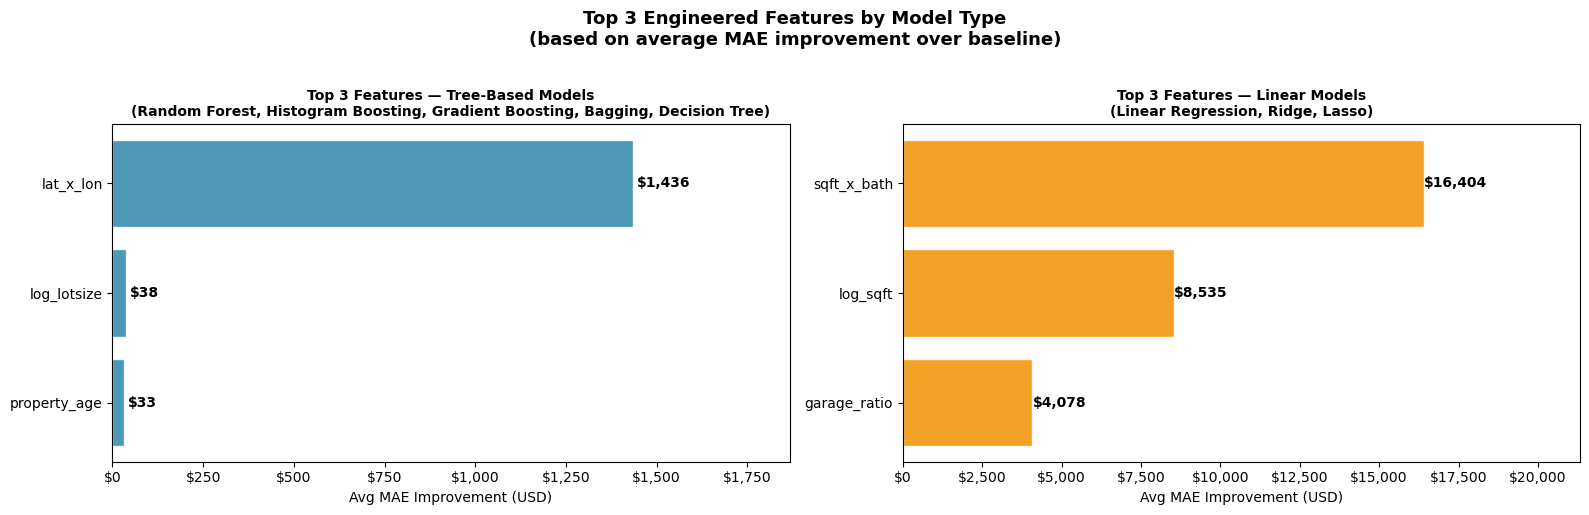

In [33]:
# ============================================================
# Visualize top 3 features for tree-based vs linear models
# Clean comparison showing only the best performing features
# for each model type
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left plot: Top 3 features for Tree-Based Models ──
top3_tree_df = pivot.nlargest(3, 'Avg Tree Models')[['Avg Tree Models']]

bars1 = axes[0].barh(
    top3_tree_df.index,
    top3_tree_df['Avg Tree Models'],
    color='#2E86AB',
    edgecolor='white',
    alpha=0.85
)

# Add value labels
for bar, val in zip(bars1, top3_tree_df['Avg Tree Models']):
    axes[0].text(
        val + 10,
        bar.get_y() + bar.get_height() / 2,
        f'${val:,.0f}',
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold'
    )

axes[0].set_xlabel('Avg MAE Improvement (USD)', fontsize=10)
axes[0].set_title(
    'Top 3 Features — Tree-Based Models\n(Random Forest, Histogram Boosting, Gradient Boosting, Bagging, Decision Tree)',
    fontweight='bold', fontsize=10
)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].invert_yaxis()
axes[0].set_xlim(0, top3_tree_df['Avg Tree Models'].max() * 1.3)

# ── Right plot: Top 3 features for Linear Models ──
top3_linear_df = pivot.nlargest(3, 'Avg Linear Models')[['Avg Linear Models']]

bars2 = axes[1].barh(
    top3_linear_df.index,
    top3_linear_df['Avg Linear Models'],
    color='#F18F01',
    edgecolor='white',
    alpha=0.85
)

# Add value labels
for bar, val in zip(bars2, top3_linear_df['Avg Linear Models']):
    axes[1].text(
        val + 10,
        bar.get_y() + bar.get_height() / 2,
        f'${val:,.0f}',
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold'
    )

axes[1].set_xlabel('Avg MAE Improvement (USD)', fontsize=10)
axes[1].set_title(
    'Top 3 Features — Linear Models\n(Linear Regression, Ridge, Lasso)',
    fontweight='bold', fontsize=10
)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].invert_yaxis()
axes[1].set_xlim(0, top3_linear_df['Avg Linear Models'].max() * 1.3)

plt.suptitle(
    'Top 3 Engineered Features by Model Type\n(based on average MAE improvement over baseline)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('top3_features_by_model_type.png', dpi=150, bbox_inches='tight')
plt.show()


Individual feature testing revealed two distinct groups of useful engineered features depending on model type. For tree-based models, `lat_x_lon` (latitude × longitude interaction) was the clear standout with an average improvement of `$1,436`, capturing geographic clustering effects that meaningfully helped Random Forest, Histogram Boosting, Gradient Boosting and Bagging. The next two features for tree-based models, `log_lotsize` (`$38`) and `property_age` (`$33`), showed only marginal improvement, suggesting that beyond location, tree-based models already capture most of the available signal from the existing features on their own.

For linear models the picture was very different, all three top features provided substantial improvement. `sqft_x_bath` was the strongest at `$16,404`, indicating the model captured the nonlinear interaction between property size and bathroom count. `log_sqft` followed with improvement of `$8,535`, and `garage_ratio` an improvement of `$4,078`.

These results confirm that the linear models benefited significantly from engineered features, while tree-based models showed little improvement from engineered features, except for `lat_x_lon`.


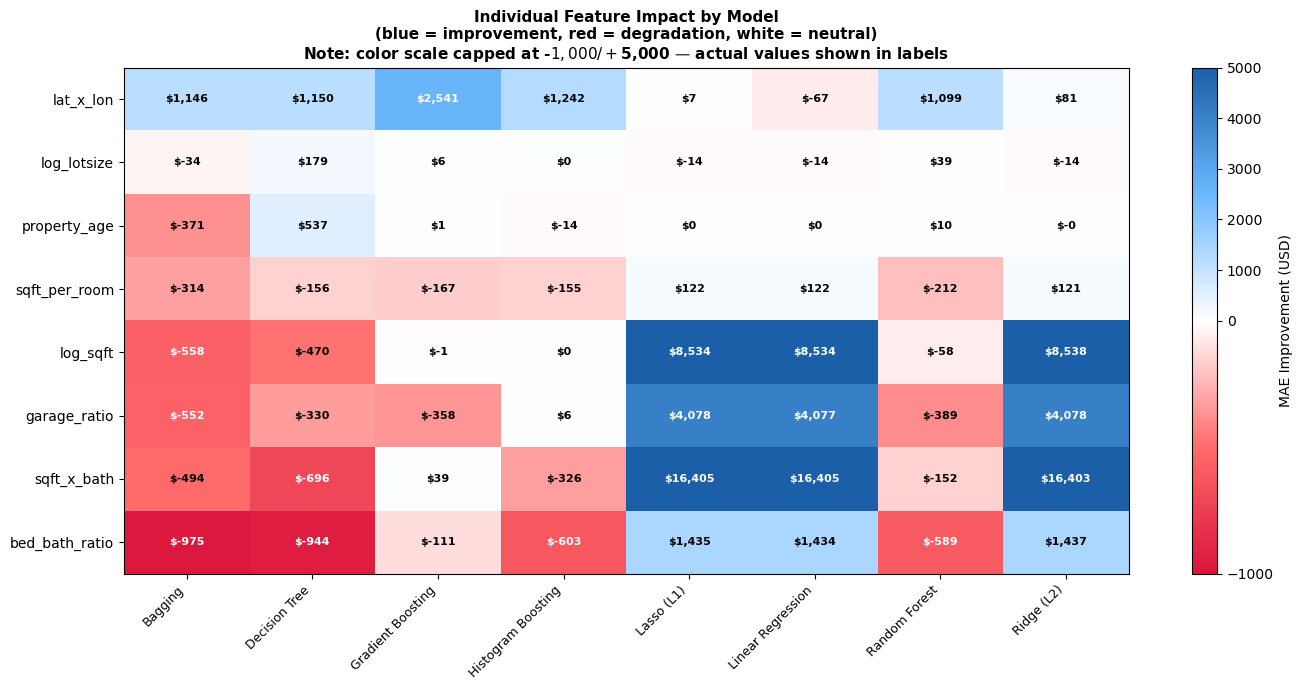

In [38]:
# ============================================================
# Heatmap of individual feature impact per model
# ============================================================
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

# Create custom colormap: red -> white -> blue
colors_map = LinearSegmentedColormap.from_list(
    'red_white_blue',
    ['#DC143C',   # dark red for most negative
     '#FF6B6B',   # light red
     '#FFFFFF',   # white at zero
     '#6BB8FF',   # light blue
     '#1A5FA8']   # dark blue for most positive
)

plot_cols = [c for c in pivot.columns 
             if c not in ['Avg All Models', 'Avg Linear Models', 
                          'Avg Tree Models', 'Average Improvement']]
heatmap_data = pivot[plot_cols]

fig, ax = plt.subplots(figsize=(14, 7))

# TwoSlopeNorm centers the colormap exactly at zero
norm = TwoSlopeNorm(vmin=-1000, vcenter=0, vmax=5000)

im = ax.imshow(
    heatmap_data.values,
    cmap=colors_map,
    norm=norm,
    aspect='auto'
)
plt.colorbar(im, ax=ax, label='MAE Improvement (USD)')

ax.set_xticks(range(len(plot_cols)))
ax.set_xticklabels(plot_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=10)
ax.set_title(
    'Individual Feature Impact by Model\n'
    '(blue = improvement, red = degradation, white = neutral)\n'
    'Note: color scale capped at -$1,000 / +$5,000 — actual values shown in labels',
    fontweight='bold', fontsize=11
)

# Add value annotations
for i in range(len(pivot.index)):
    for j in range(len(plot_cols)):
        val = heatmap_data.values[i, j]
        normalized = norm(val)
        text_color = 'white' if (normalized < 0.25 or normalized > 0.75) else 'black'
        ax.text(j, i, f'${val:,.0f}',
                ha='center', va='center',
                fontsize=8, color=text_color,
                fontweight='bold')

plt.tight_layout()
plt.savefig('feature_impact_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# ============================================================
# Top 3 features based on best performing models only
# Based on Part 1 results — top 3 models were:
# Random Forest, Histogram Boosting, Gradient Boosting
# ============================================================

best_models = ['Random Forest', 'Histogram Boosting', 'Gradient Boosting']

# Calculate average improvement across best models only
pivot['Avg Improvement (Best Models)'] = pivot[best_models].mean(axis=1)
pivot_best = pivot.sort_values('Avg Improvement (Best Models)', ascending=False)

print("\n" + "=" * 60)
print("TOP 3 FEATURES FOR BEST PERFORMING MODELS")
print(f"Based on: {', '.join(best_models)}")
print("=" * 60)

top3_best = pivot_best.head(3)
for i, (feat, row) in enumerate(top3_best.iterrows(), 1):
    print(f"\n#{i}: {feat}")
    print(f"    Avg Improvement (best models): ${row['Avg Improvement (Best Models)']:,.0f}")
    for model in best_models:
        print(f"    {model}: ${row[model]:,.0f}")


TOP 3 FEATURES FOR BEST PERFORMING MODELS
Based on: Random Forest, Histogram Boosting, Gradient Boosting

#1: lat_x_lon
    Avg Improvement (best models): $1,627
    Random Forest: $1,099
    Histogram Boosting: $1,242
    Gradient Boosting: $2,541

#2: log_lotsize
    Avg Improvement (best models): $15
    Random Forest: $39
    Histogram Boosting: $0
    Gradient Boosting: $6

#3: property_age
    Avg Improvement (best models): $-1
    Random Forest: $10
    Histogram Boosting: $-14
    Gradient Boosting: $1


### Part 2: Discussion [3 pts]

Reflect on the impact of your new features:

- Did any models show notable improvement in performance?

Linear models showed the most notable improvement — Ridge, Lasso, and Linear Regression all reduced MAE by approximately `$16,400` with the addition of `sqft_x_bath`. Tree-based models showed minimal change in either direction, with improvements generally under $1,500.

- Which new features seemed to help — and in which models?

`sqft_x_bath`, `log_sqft`, and garage_ratio were the top three features for linear models, while `lat_x_lon` was the only feature that meaningfully helped tree-based models, improving Random Forest, Histogram Boosting, Gradient Boosting and Bagging by `$1,099` to `$2,541`.

- Do you have any hypotheses about why a particular feature helped (or didn’t)?

Linear models benefited from `sqft_x_bath` and `log_sqft` possibly because they are non-linear and combined effect of size and bathrooms is not typically captured on their own without explicit engineering. Tree-based models benefited from `lat_x_lon` possibly because it provides a more direct geographic signal than it does separately, helping the tree models identify location-based clusters more efficiently. Features like `sqft_per_room` likely hurt due to redundancy with similar existing features and noise, such as the `roomcnt` variable.




> Your text here

### Part 3: Feature Selection [6 pts]

Using the full set of features (original + engineered):
- Apply **feature selection** methods to investigate whether you can improve performance.
  - You may use forward selection, backward selection, or feature importance from tree-based models.
- For each model, identify the **best-performing subset of features**.
- Re-run each model using only those features (with default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [5]:
# Add as many cells as you need


### Part 3: Discussion [3 pts]

Analyze the effect of feature selection on your models:

- Did performance improve for any models after reducing the number of features?

- Which features were consistently retained across models?

- Were any of your newly engineered features selected as important?


> Your text here

### Part 4: Fine-Tuning Your Three Models [6 pts]

In this final phase of Milestone 2, you’ll select and refine your **three most promising models and their corresponding data pipelines** based on everything you've done so far, and pick a winner!

1. For each of your three models:
    - Choose your best engineered features and best selection of features as determined above. 
   - Perform hyperparameter tuning using `sweep_parameters`, `GridSearchCV`, `RandomizedSearchCV`, `Optuna`, etc. as you have practiced in previous homeworks. 
3. Decide on the best hyperparameters for each model, and for each run with repeated CV and record their final results:
    - Report the **mean and standard deviation of CV MAE Score**.  

In [6]:
# Add as many cells as you need


### Part 4: Discussion [3 pts]

Reflect on your tuning process and final results:

- What was your tuning strategy for each model? Why did you choose those hyperparameters?
- Did you find that certain types of preprocessing or feature engineering worked better with specific models?


> Your text here

### Part 5: Final Model and Design Reassessment [6 pts]

In this part, you will finalize your best-performing model.  You’ll also consolidate and present the key code used to run your model on the preprocessed dataset.
**Requirements:**

- Decide one your final model among the three contestants. 

- Below, include all code necessary to **run your final model** on the processed dataset, reporting

    - Mean and standard deviation of CV MAE Score.
    
    - Test score on held-out test set. 




In [7]:
# Add as many cells as you need


### Part 5: Discussion [8 pts]

In this final step, your goal is to synthesize your entire modeling process and assess how your earlier decisions influenced the outcome. Please address the following:

1. Model Selection:
- Clearly state which model you selected as your final model and why.

- What metrics or observations led you to this decision?

- Were there trade-offs (e.g., interpretability vs. performance) that influenced your choice?

2. Revisiting an Early Decision

- Identify one specific preprocessing or feature engineering decision from Milestone 1 (e.g., how you handled missing values, how you scaled or encoded a variable, or whether you created interaction or polynomial terms).

- Explain the rationale for that decision at the time: What were you hoping it would achieve?

- Now that you've seen the full modeling pipeline and final results, reflect on whether this step helped or hindered performance. Did you keep it, modify it, or remove it?

- Justify your final decision with evidence—such as validation scores, visualizations, or model diagnostics.

3. Lessons Learned

- What insights did you gain about your dataset or your modeling process through this end-to-end workflow?

- If you had more time or data, what would you explore next?

> Your text here